# 🤖 Hibrit (Topluluk / Ensemble) Model Değerlendirmesi

Bu aşamada, klasik makine öğrenmesi modeli (LightGBM/SVC) ile derin öğrenme modelinin (BERT) güçlerini birleştirdiğimiz **Hibrit Model**in başarısını ölçeceğiz.

Modelimiz (Soft-Voting mantığıyla) her iki modelin de yüzdelik olasılıklarını alıp, onları toplayarak nihai kararı vermektedir.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, accuracy_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from hybrid_model import HybridEnsembleClassifier

## 1. Verinin ve Modelin Yüklenmesi

In [2]:
# Aynı test setini (random_state=42) tekrar ayırıyoruz
df = pd.read_csv('data/processed/reviews_cleaned.csv')
df = df.dropna(subset=['yorum'])

train_df, test_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['label'])
print(f"Test Seti Boyutu: {len(test_df)}")

# Hibrit Modeli Başlat
hybrid_model = HybridEnsembleClassifier()

Test Seti Boyutu: 12395
Hybrid Model loading on: cuda
Loading SVC and TF-IDF...
Loading Fine-Tuned BERT...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 2. Test Seti Üzerinde Tahminlerin Alınması

Bu işlem GPU üzerinde yaklaşık 1-2 dakika sürebilir.

In [3]:
predictions = []
y_true = test_df['label'].tolist()
texts = test_df['yorum'].tolist()

for text in tqdm(texts, desc="Hibrit Model İle Tahmin Ediliyor"):
    label, _ = hybrid_model.predict(text)
    predictions.append(label)


Hibrit Model İle Tahmin Ediliyor:   0%|          | 0/12395 [00:00<?, ?it/s]

c:\Users\TAHA\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 3. Sonuçlar ve Karşılaştırma

In [4]:
print("=======================================================")
print("        HİBRİT MODEL TEST SONUÇLARI")
print("=======================================================")
print(classification_report(y_true, predictions))

hybrid_f1 = f1_score(y_true, predictions, average='weighted')
hybrid_acc = accuracy_score(y_true, predictions)

print(f"Hibrit F1 Score: {hybrid_f1:.4f}")
print(f"Hibrit Accuracy: {hybrid_acc:.4f}")

        HİBRİT MODEL TEST SONUÇLARI
              precision    recall  f1-score   support

    negative       0.87      0.57      0.69      5808
     neutral       0.32      0.81      0.46      2018
    positive       0.91      0.69      0.79      4569

    accuracy                           0.66     12395
   macro avg       0.70      0.69      0.65     12395
weighted avg       0.80      0.66      0.69     12395

Hibrit F1 Score: 0.6893
Hibrit Accuracy: 0.6566


C:\Users\TAHA\AppData\Local\Temp\ipykernel_15004\981434233.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=f1_scores, palette='viridis')


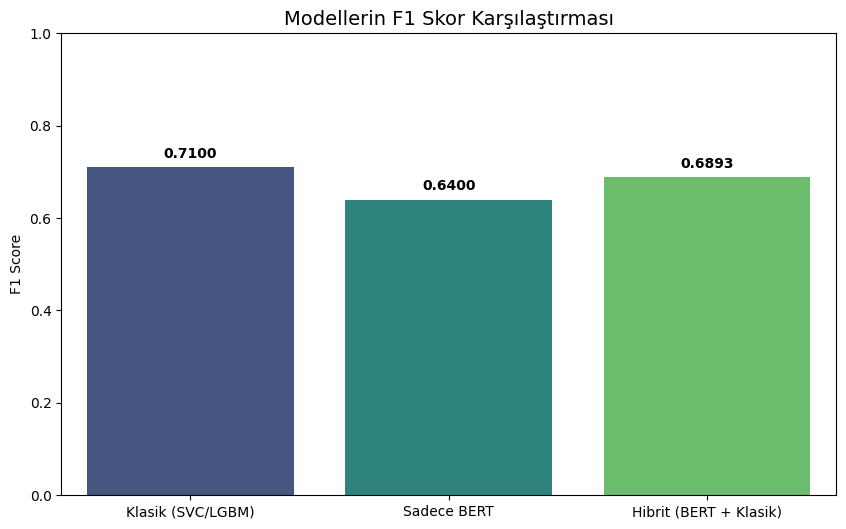

In [5]:
# Önceki sonuçlarla (Hardcoded) görselleştirme
models = ['Klasik (SVC/LGBM)', 'Sadece BERT', 'Hibrit (BERT + Klasik)']
f1_scores = [0.71, 0.64, hybrid_f1]

plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=f1_scores, palette='viridis')
plt.title('Modellerin F1 Skor Karşılaştırması', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1.0)

for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()